In [77]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [78]:
data = pd.read_table('dane.data', header=None, decimal=',')

#add column names
data.columns = [f"Col{i}" for i in range(data.shape[1])] 

#suffle data
data = data.sample(frac=1, axis=0).reset_index(drop=True)

X = data.iloc[:, :-1].apply(pd.to_numeric, errors='raise')
y = pd.to_numeric(data.iloc[:, -1], errors='raise')




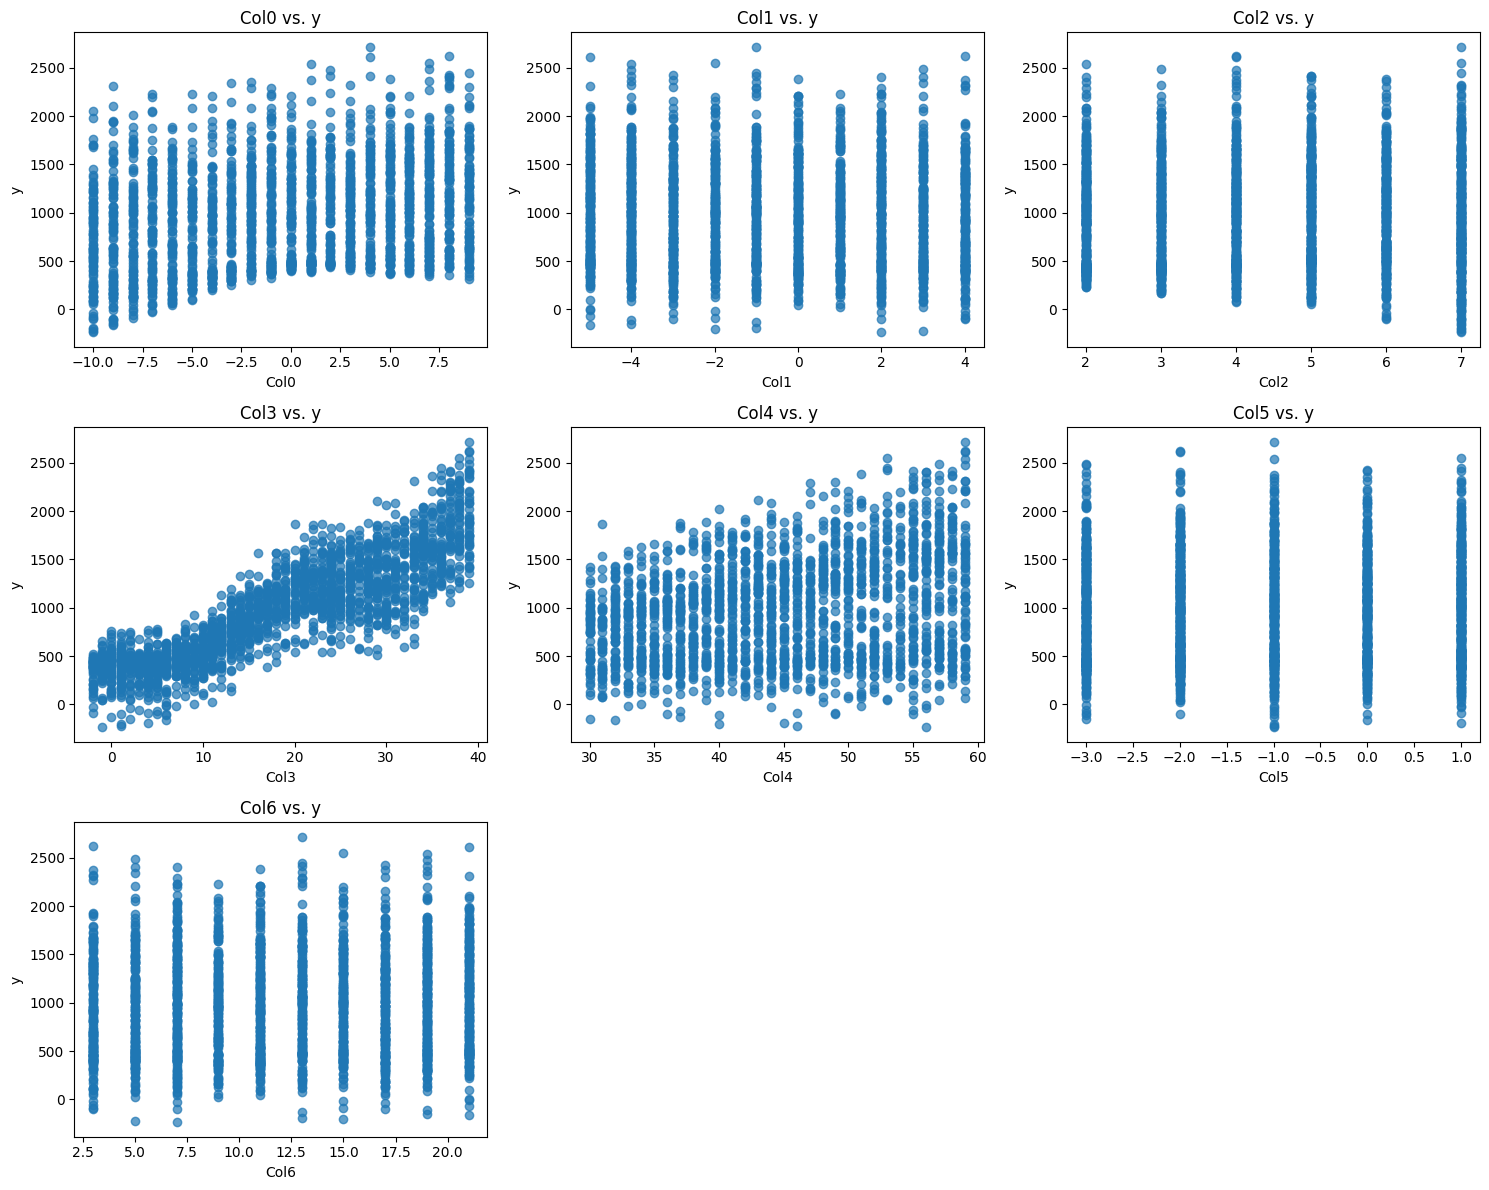

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

num_cols = len(X.columns)
cols = 3  
rows = math.ceil(num_cols / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()  

for i, col in enumerate(X.columns):
    axes[i].scatter(X[col], y, alpha=0.7)
    axes[i].set_title(f'{col} vs. y')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('y')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()



Correlation Matrix (Input Features):
          Col0      Col1      Col2      Col3      Col4      Col5      Col6
Col0  1.000000  0.009175 -0.012969  0.027513  0.009519  0.019575 -0.009175
Col1  0.009175  1.000000 -0.039719 -0.027856 -0.002909 -0.005894 -1.000000
Col2 -0.012969 -0.039719  1.000000  0.016406  0.032684 -0.036646  0.039719
Col3  0.027513 -0.027856  0.016406  1.000000  0.011885 -0.000931  0.027856
Col4  0.009519 -0.002909  0.032684  0.011885  1.000000  0.000313  0.002909
Col5  0.019575 -0.005894 -0.036646 -0.000931  0.000313  1.000000  0.005894
Col6 -0.009175 -1.000000  0.039719  0.027856  0.002909  0.005894  1.000000


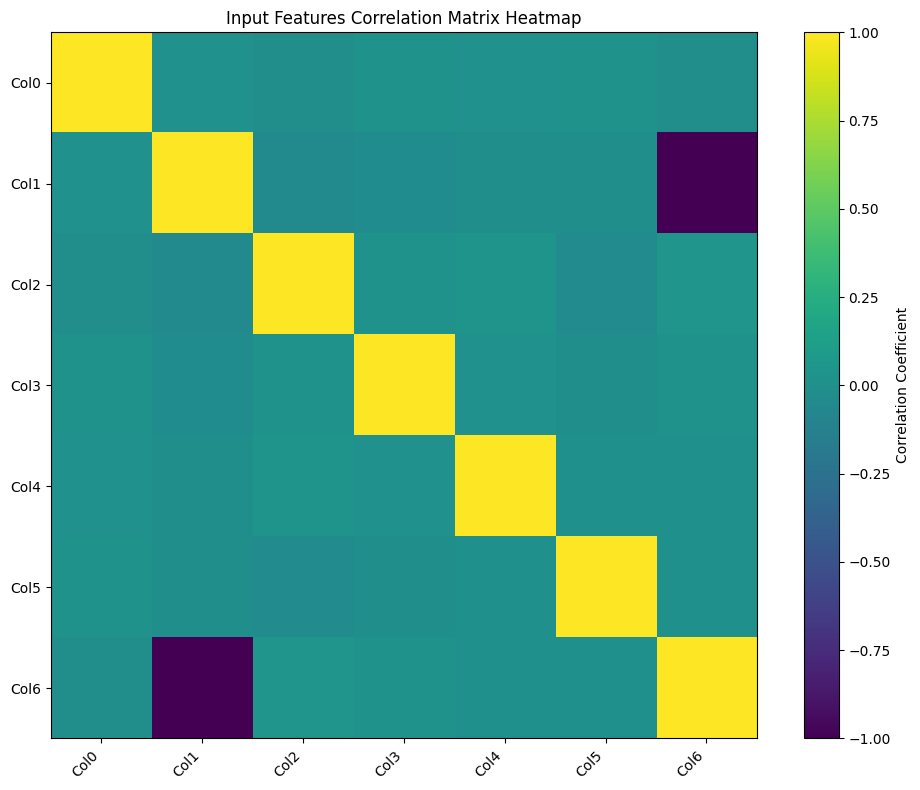

In [80]:
corr_matrix = X.corr()
print("\nCorrelation Matrix (Input Features):")
print(corr_matrix)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='viridis', interpolation='none')
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title('Input Features Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()


In [81]:
class CustomStandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None
        
    def fit(self, X):
        X = np.asarray(X, dtype=np.float64)
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)
        return self
    
    def transform(self, X):
        X = np.asarray(X, dtype=np.float64)
        return (X - self.mean_) / self.std_
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)
    
    
class CustomMinMaxScaler:
    def __init__(self, feature_range=(0, 1)):
        self.feature_range = feature_range
        self.data_min_ = None
        self.data_max_ = None
        
    def fit(self, X):
        X = np.asarray(X, dtype=np.float64)
        self.data_min_ = np.min(X, axis=0)
        self.data_max_ = np.max(X, axis=0)
        return self
    
    def transform(self, X):
        X = np.asarray(X, dtype=np.float64)
        X_std = (X - self.data_min_) / (self.data_max_ - self.data_min_)
        scale_min, scale_max = self.feature_range
        X_scaled = X_std * (scale_max - scale_min) + scale_min
        return X_scaled
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [82]:

custom_minmax_scaler = CustomMinMaxScaler(feature_range=(0, 1))
X= custom_minmax_scaler.fit_transform(X)

print("MinMax Transformation:")
print(X)



print(y)

MinMax Transformation:
[[0.78947368 0.22222222 1.         ... 0.65517241 0.25       0.77777778]
 [0.63157895 0.77777778 0.6        ... 0.96551724 0.5        0.22222222]
 [0.05263158 0.11111111 0.         ... 0.03448276 0.25       0.88888889]
 ...
 [0.78947368 0.44444444 0.         ... 0.55172414 0.         0.55555556]
 [0.47368421 0.         0.4        ... 0.82758621 0.25       1.        ]
 [0.84210526 0.22222222 0.4        ... 0.55172414 0.5        0.77777778]]
0       1875.99
1        735.68
2        877.21
3        590.63
4       1228.89
         ...   
1994     492.58
1995    1005.08
1996    1779.15
1997     732.39
1998    1401.52
Name: Col7, Length: 1999, dtype: float64


In [83]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)


Training set shape: (1199, 7) (1199,)
Validation set shape: (400, 7) (400,)
Test set shape: (400, 7) (400,)


In [84]:
def MSE(y, y_pred):
    return np.mean((y - y_pred) ** 2)

In [85]:
def safe_sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

In [86]:
def safe_polynomial(x):
    x = np.clip(x, -10, 10)  
    return x ** 4

In [87]:
def leaky_relu(x):
    return np.where(x > 0, x, 0.01 * x)

In [88]:
def relu(x):
    return np.maximum(0, x)

In [89]:
def predict(x):
    return safe_polynomial(x)
    

In [90]:
def model(X, w , bias):
    return predict(np.dot(X, w) + bias)

In [91]:
def SGD_step(X, y, w, bias, lr):
    y_pred = model(X, w, bias)
    loss = MSE(y, y_pred)

    grad_w = np.dot(X.T, (y_pred - y))
    grad_bias = np.sum(y_pred - y)

    grad_w = np.clip(grad_w, -5.0, 5.0)
    grad_bias = np.clip(grad_bias, -5.0, 5.0)

    w -= lr * grad_w
    bias -= lr * grad_bias
    return w, bias, loss

In [92]:
def train(X, y, w, bias, lr, epochs, minimal_loss):
    for epoch in range(epochs):
        batch = 32
        epoch_losses = []
        for i in range(0, len(y), batch):
            w, bias, loss = SGD_step(X[i:i+batch], y[i:i+batch], w, bias, lr)
            epoch_losses.append(loss)

        avg_loss = np.mean(epoch_losses)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {avg_loss}")
            
    if loss < minimal_loss:
        minimal_loss = loss
    return w, bias

In [93]:
import random 

starting_w = np.random.rand(X_train.shape[1])
starting_bias = 0.2137
learning_rate = 0.01
epochs = 31
minimal_loss = 1e9

w, bias = train(X_train, y_train, starting_w, starting_bias, learning_rate, epochs, minimal_loss)


Epoch 0, Loss: 441395.6544038663
Epoch 10, Loss: 33637.35627590441
Epoch 20, Loss: 34322.63370346586
Epoch 30, Loss: 34322.63370346586


In [94]:
y_val_pred = model(X_val, w, bias)
val_loss = MSE(y_val, y_val_pred)
print("\nValidation:")
print("Validation MSE:", val_loss)


Validation:
Validation MSE: 35133.23644898818


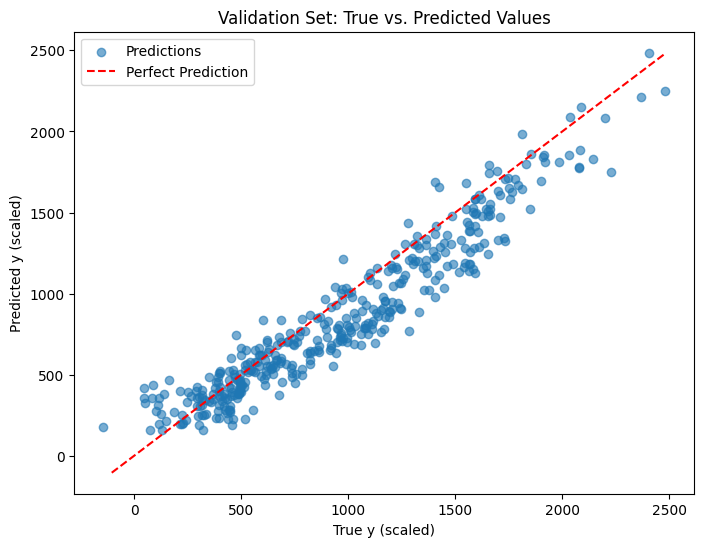

In [95]:
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_val_pred, alpha=0.6, label='Predictions')
plt.xlabel('True y (scaled)')
plt.ylabel('Predicted y (scaled)')
plt.title('Validation Set: True vs. Predicted Values')
min_val = min(y_test.min(), y_val_pred.min())
max_val = max(y_test.max(), y_val_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

plt.legend()
plt.show()

In [96]:
y_test_pred = model(X_test, w, bias)
test_loss = MSE(y_test, y_test_pred)
print("\nTest:")
print("Test Loss (MSE):", test_loss)


Test:
Test Loss (MSE): 34019.49729938374


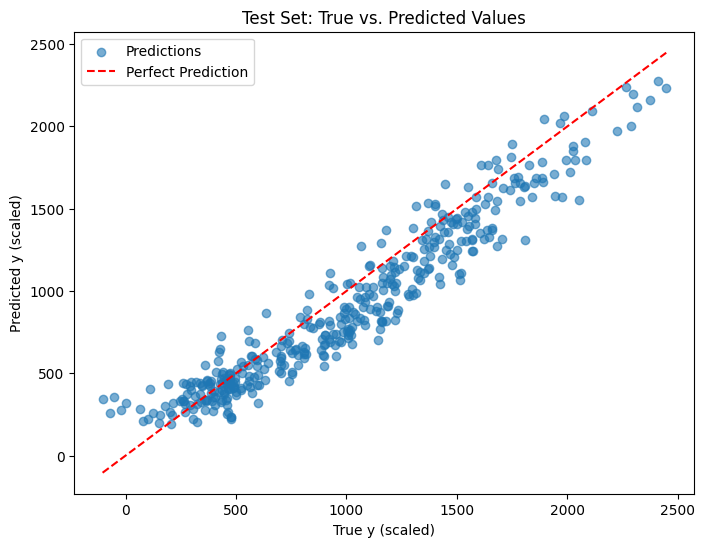

In [97]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6, label='Predictions')
plt.xlabel('True y (scaled)')
plt.ylabel('Predicted y (scaled)')
plt.title('Test Set: True vs. Predicted Values')
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
plt.legend()
plt.show()

In [98]:
#SGD with regularization
def SGD_step(X, y, w, bias, lr, reg_type=None, reg_lambda=0, elastic_alpha=0.5):
    # Pojedynczy krok mini-batch SGD z opcjonalną regularyzacją:
    #   - reg_type: 'l1', 'l2', 'elastic' lub None
    #   - reg_lambda: parametr regluaryzacji 
    #   - elastic_alpha: parametr mieszający w elastic net, gdzie 0 oznacza L2, 1 L1

    y_pred = model(X, w, bias)
    error = y_pred - y
    loss = MSE(y, y_pred)
    
    if reg_type == 'l1':
        reg_loss = reg_lambda * np.sum(np.abs(w))
        loss += reg_loss
        grad_reg = reg_lambda * np.sign(w)
    elif reg_type == 'l2':
        reg_loss = (reg_lambda / 2) * np.sum(w**2)
        loss += reg_loss
        grad_reg = reg_lambda * w
    elif reg_type == 'elastic':
        reg_loss = reg_lambda * (elastic_alpha * np.sum(np.abs(w)) + (1 - elastic_alpha) / 2 * np.sum(w**2))
        loss += reg_loss
        grad_reg = reg_lambda * (elastic_alpha * np.sign(w) + (1 - elastic_alpha) * w)
    else:
        grad_reg = 0  

    grad_w = np.dot(X.T, error) + grad_reg  
    grad_bias = np.sum(error)    

    grad_w = np.clip(grad_w, -5.0, 5.0)
    grad_bias = np.clip(grad_bias, -5.0, 5.0)          

    w -= lr * grad_w
    bias -= lr * grad_bias
    return w, bias, loss



In [99]:
#train model with regularization
def train_model(X, y, w, bias, lr, epochs, reg_type=None, reg_lambda=0, elastic_alpha=0.5, batch_size=32):
    losses = []
    for epoch in range(epochs):
        epoch_loss = []
        indices = np.arange(len(y))
        np.random.shuffle(indices)
        for start in range(0, len(y), batch_size):
            end = start + batch_size
            batch_indices = indices[start:end]
            X_batch = X[batch_indices]
            y_batch = y.iloc[batch_indices] if isinstance(y, pd.Series) else y[batch_indices]
            w, bias, loss = SGD_step(X_batch, y_batch, w, bias, lr, reg_type, reg_lambda, elastic_alpha)
            epoch_loss.append(loss)
        avg_epoch_loss = np.mean(epoch_loss)
        losses.append(avg_epoch_loss)
        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {avg_epoch_loss}")
    return w, bias, losses


In [100]:
def random_search(X_train, y_train, X_val, y_val, reg_type, n_iter=100, epochs=31):
    best_val_loss = np.inf
    best_params = {}
    results = []  
    
    for i in range(n_iter):
        lr = 10**np.random.uniform(-4, -1)           # Learning rate: [1e-4, 1e-1]
        reg_lambda = 10**np.random.uniform(-4, 1)      # reg_lambda: [1e-4, 1e1]
        if reg_type == 'elastic':
            elastic_alpha = np.random.uniform(0, 1)    # elastic_alpha: [0,1]
        else:
            elastic_alpha = 0.5
        
        w_init = np.random.rand(X_train.shape[1])
        bias_init = np.random.rand()
        
        w_trained, bias_trained, _ = train_model(X_train, y_train, w_init, bias_init,
                                                 lr, epochs, reg_type, reg_lambda, elastic_alpha)
    
        # Validation Loss
        y_val_pred = model(X_val, w_trained, bias_trained)
        val_loss = MSE(y_val, y_val_pred)
    
        # Save results
        results.append({
            'iteration': i,
            'lr': lr,
            'reg_lambda': reg_lambda,
            'elastic_alpha': elastic_alpha,
            'val_loss': val_loss
        })
    
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_params = {
                'lr': lr,
                'reg_lambda': reg_lambda,
                'elastic_alpha': elastic_alpha if reg_type=='elastic' else None,
                'w': w_trained,
                'bias': bias_trained,
                'val_loss': val_loss
            }
        if i % 100 == 0:
            print(f"Iteracja {i}: lr={lr:.5f}, reg_lambda={reg_lambda:.5f}, "
                  f"elastic_alpha={elastic_alpha if reg_type=='elastic' else 'N/A'}, val_loss={val_loss:.5f}")
    print(f"Best validation lost {reg_type}: {best_val_loss:.5f}")
    return best_params, results

In [101]:
print("Random search for regularization L1:")
best_l1, results_l1 = random_search(X_train, y_train, X_val, y_val, reg_type='l1', n_iter=100, epochs=31)

print("\nRandom search for regularization L2:")
best_l2, results_l2 = random_search(X_train, y_train, X_val, y_val, reg_type='l2', n_iter=100, epochs=31)

print("\nRandom search for regularization Elastic Net:")
best_elastic, results_elastic = random_search(X_train, y_train, X_val, y_val, reg_type='elastic', n_iter=100, epochs=31)

Random search for regularization L1:
Epoch 0, Loss: 839808.7398780445
Epoch 10, Loss: 28559.291682259227
Epoch 20, Loss: 28765.44446265163
Epoch 30, Loss: 29434.89540001435
Iteracja 0: lr=0.00440, reg_lambda=1.25060, elastic_alpha=N/A, val_loss=26925.64843
Best validation lost l1: 26925.64843

Random search for regularization L2:
Epoch 0, Loss: 1043299.9993637418
Epoch 10, Loss: 551688.9883393745
Epoch 20, Loss: 258837.92019657942
Epoch 30, Loss: 166091.25074483585
Iteracja 0: lr=0.00016, reg_lambda=2.10352, elastic_alpha=N/A, val_loss=162666.64090
Best validation lost l2: 162666.64090

Random search for regularization Elastic Net:
Epoch 0, Loss: 250029.80024020025
Epoch 10, Loss: 44697.66409085701
Epoch 20, Loss: 43023.524015093724
Epoch 30, Loss: 48724.94939167219
Iteracja 0: lr=0.01431, reg_lambda=0.00012, elastic_alpha=0.5966529065782035, val_loss=41443.50209
Best validation lost elastic: 41443.50209



Test Set:
L1 Regularization - Test Loss (MSE): 27390.57948


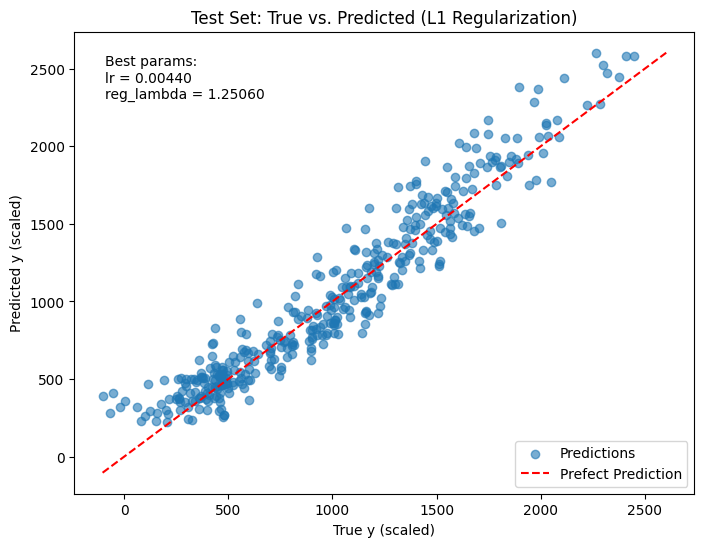

L2 Regularization - Test Loss (MSE): 149371.19696


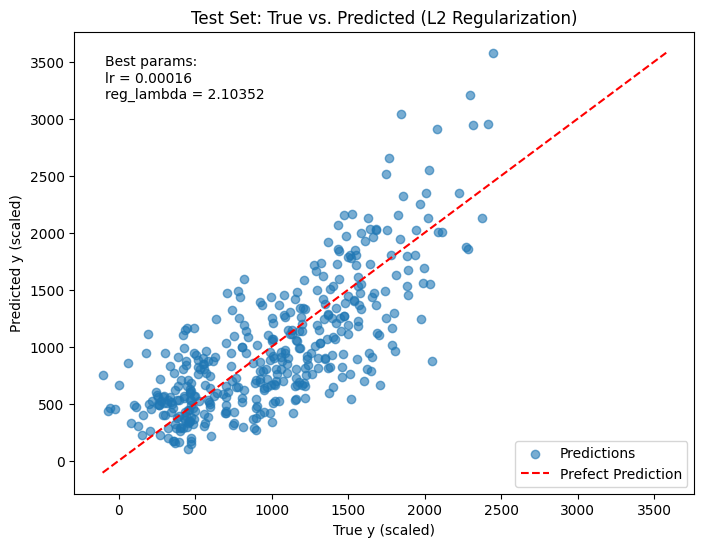

Elastic Net Regularization - Test Loss (MSE): 41256.13234


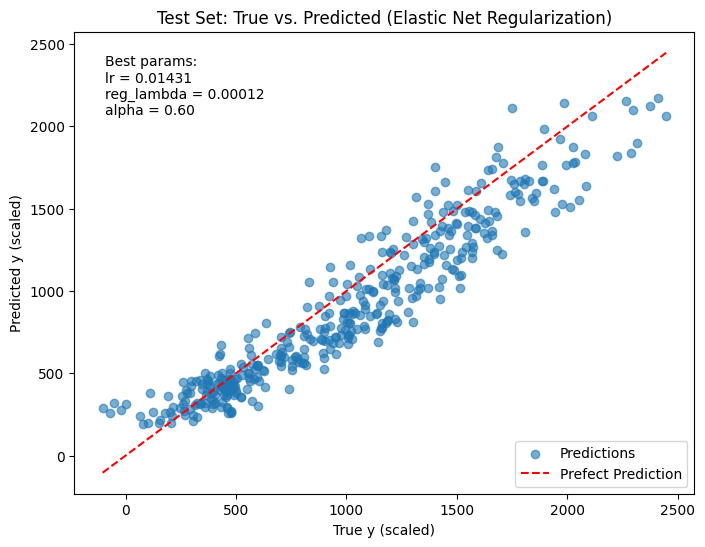

In [102]:
def plot_test_results(y_true, y_pred, reg_name, best_params):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.6, label='Predictions')
    plt.xlabel('True y (scaled)')
    plt.ylabel('Predicted y (scaled)')
    plt.title(f'Test Set: True vs. Predicted ({reg_name} Regularization)')
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Prefect Prediction')

    if reg_name == "Elastic Net":
        annot_text = f"Best params:\nlr = {best_params['lr']:.5f}\nreg_lambda = {best_params['reg_lambda']:.5f}\nalpha = {best_params['elastic_alpha']:.2f}"
    else:
        annot_text = f"Best params:\nlr = {best_params['lr']:.5f}\nreg_lambda = {best_params['reg_lambda']:.5f}"
    plt.annotate(annot_text, xy=(0.05, 0.95), xycoords='axes fraction',
                 fontsize=10, backgroundcolor='white', verticalalignment='top')
    plt.legend()
    plt.show()

print("\nTest Set:")
for reg_name, best_model in zip(["L1", "L2", "Elastic Net"], [best_l1, best_l2, best_elastic]):
    y_test_pred = model(X_test, best_model['w'], best_model['bias'])
    test_loss = MSE(y_test, y_test_pred)
    print(f"{reg_name} Regularization - Test Loss (MSE): {test_loss:.5f}")
    plot_test_results(y_test, y_test_pred, reg_name, best_model)


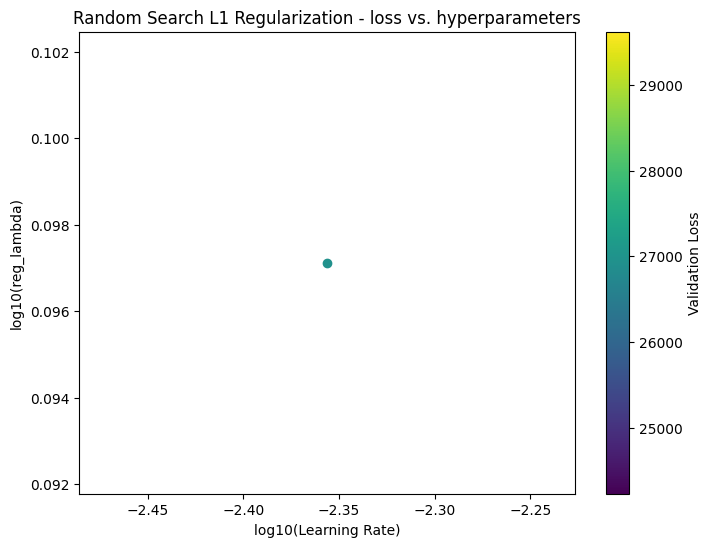

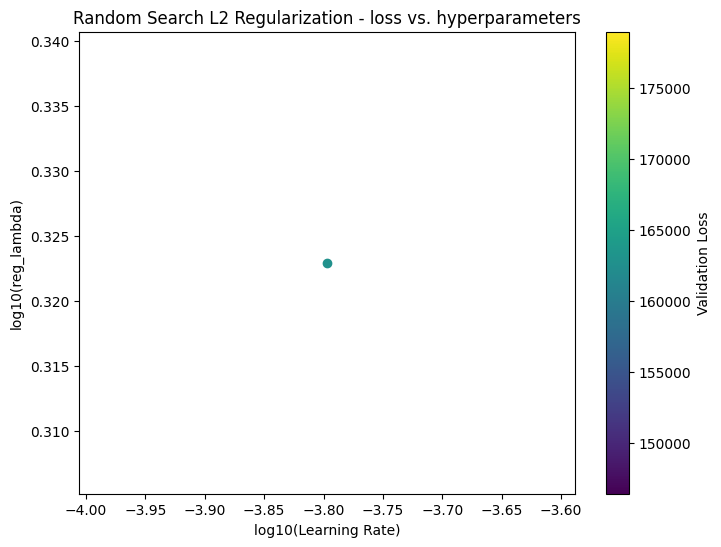

In [103]:
def plot_random_search_results(results, reg_type):
    lr_vals = [res['lr'] for res in results]
    lambda_vals = [res['reg_lambda'] for res in results]
    val_losses = [res['val_loss'] for res in results]
    
    plt.figure(figsize=(8,6))
    sc = plt.scatter(np.log10(lr_vals), np.log10(lambda_vals), c=val_losses, cmap='viridis')
    plt.colorbar(sc, label='Validation Loss')
    plt.xlabel('log10(Learning Rate)')
    plt.ylabel('log10(reg_lambda)')
    plt.title(f'Random Search {reg_type} - loss vs. hyperparameters')
    plt.show()

plot_random_search_results(results_l1, "L1 Regularization")
plot_random_search_results(results_l2, "L2 Regularization")

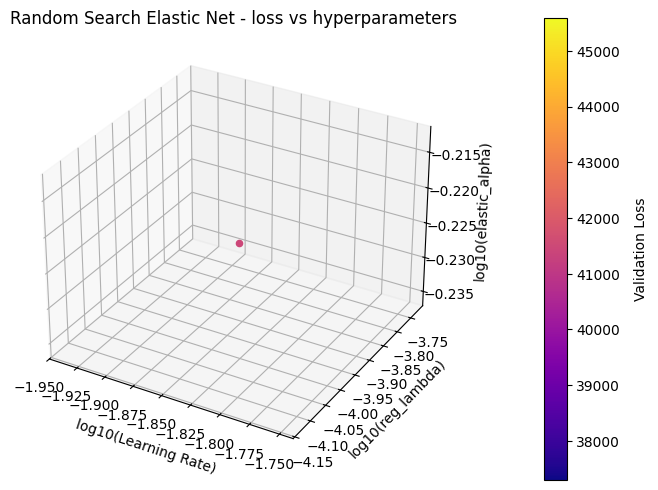

In [104]:
lr_vals = [res['lr'] for res in results_elastic]
lambda_vals = [res['reg_lambda'] for res in results_elastic]
alpha_vals = [res['elastic_alpha'] for res in results_elastic]
val_losses = [res['val_loss'] for res in results_elastic]


from mpl_toolkits.mplot3d import Axes3D  

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d') 

sc = ax.scatter(np.log10(lr_vals), np.log10(lambda_vals), np.log10(alpha_vals),
                c=val_losses, cmap='plasma')

cbar = fig.colorbar(sc, ax=ax, pad=0.15)
cbar.set_label('Validation Loss', labelpad=10)

ax.set_xlabel('log10(Learning Rate)')
ax.set_ylabel('log10(reg_lambda)')
ax.set_zlabel('log10(elastic_alpha)')

ax.set_title('Random Search Elastic Net - loss vs hyperparameters')

plt.show()



Learning Curve for l1 Regularization:
Best params:
lr = 0.00440
reg_lambda = 1.25060
Epoch 0, Loss: 1131240.924481032
Epoch 10, Loss: 691691.3240279054
Epoch 20, Loss: 193667.3508632353
Epoch 30, Loss: 146919.43692897278
Epoch 0, Loss: 876839.7978086841
Epoch 10, Loss: 647826.7154711155
Epoch 20, Loss: 359678.3376139466
Epoch 30, Loss: 253468.21572156984
Epoch 0, Loss: 1309864.9414917836
Epoch 10, Loss: 1293473.940146212
Epoch 20, Loss: 1186035.5831359243
Epoch 30, Loss: 873979.0099517459
Epoch 0, Loss: 1662691.8943218319
Epoch 10, Loss: 1548097.6731525366
Epoch 20, Loss: 1236480.2517939224
Epoch 30, Loss: 764482.0965413906
Epoch 0, Loss: 1445269.7875183856
Epoch 10, Loss: 1231110.24435432
Epoch 20, Loss: 824583.5990692258
Epoch 30, Loss: 403571.74526463647
Reg l1 - Fraction: 0.010, Average MSE: 457044.79251
Epoch 0, Loss: 996111.5792740413
Epoch 10, Loss: 794414.5099681919
Epoch 20, Loss: 445429.8601915829
Epoch 30, Loss: 209049.40182492384
Epoch 0, Loss: 1197070.0880350657
Epoch 10,

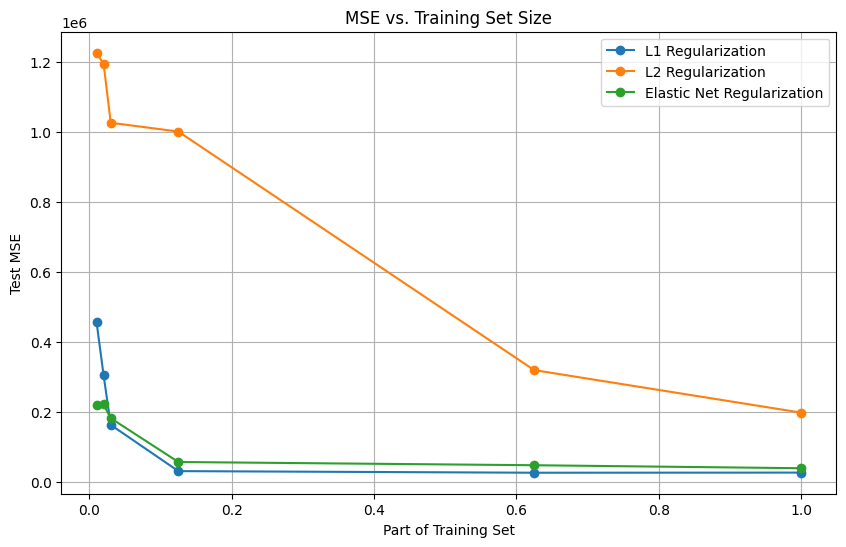

In [105]:
fractions = [0.01, 0.02, 0.03, 0.125, 0.625, 1.0]
n_runs = 5  



def compute_learning_curve(X_train, y_train, X_test, y_test, reg_type, best_params, n_runs=5, epochs=31, batch_size=32):
    lr = best_params['lr']
    reg_lambda = best_params['reg_lambda']
    elastic_alpha = best_params.get('elastic_alpha', 0.5)
    print (f"\nLearning Curve for {reg_type} Regularization:")
    print(f"Best params:\nlr = {lr:.5f}\nreg_lambda = {reg_lambda:.5f}")
    test_errors = []
    for frac in fractions:
        run_errors = []
        for _ in range(n_runs):

            n_samples = int(len(X_train) * frac)

            indices = np.random.choice(len(X_train), n_samples, replace=False)
            X_sub = X_train[indices]

            if isinstance(y_train, pd.Series):
                y_sub = y_train.iloc[indices]
            else:
                y_sub = y_train[indices]
            
            w_init = np.random.rand(X_train.shape[1])
            bias_init = np.random.rand()
            
            w_trained, bias_trained, _ = train_model(X_sub, y_sub, w_init, bias_init,
                                                     lr, epochs, reg_type, reg_lambda, elastic_alpha, batch_size=batch_size)

            y_test_pred = model(X_test, w_trained, bias_trained)

            error = MSE(y_test, y_test_pred)
            run_errors.append(error)
        avg_error = np.mean(run_errors)
        test_errors.append(avg_error)
        print(f"Reg {reg_type} - Fraction: {frac:.3f}, Average MSE: {avg_error:.5f}")
    return fractions, test_errors

fractions_l1, errors_l1 = compute_learning_curve(X_train, y_train, X_test, y_test, 'l1', best_l1, n_runs=n_runs)
fractions_l2, errors_l2 = compute_learning_curve(X_train, y_train, X_test, y_test, 'l2', best_l2, n_runs=n_runs)
fractions_elastic, errors_elastic = compute_learning_curve(X_train, y_train, X_test, y_test, 'elastic', best_elastic, n_runs=n_runs)

plt.figure(figsize=(10, 6))
plt.plot(fractions_l1, errors_l1, marker='o', label='L1 Regularization')
plt.plot(fractions_l2, errors_l2, marker='o', label='L2 Regularization')
plt.plot(fractions_elastic, errors_elastic, marker='o', label='Elastic Net Regularization')
plt.xlabel('Part of Training Set')
plt.ylabel('Test MSE')
plt.title('MSE vs. Training Set Size')
plt.legend()
plt.grid(True)
plt.show()


Analitical solution:
Params: [-197.34599428  458.40854291 -109.19042751  -22.45662543 1558.69807885
  531.43904339   11.91880754  -88.15556677]
Loss MSE on validation set: 28874.384820511565
Loss MSE on test set: 25840.877823956544


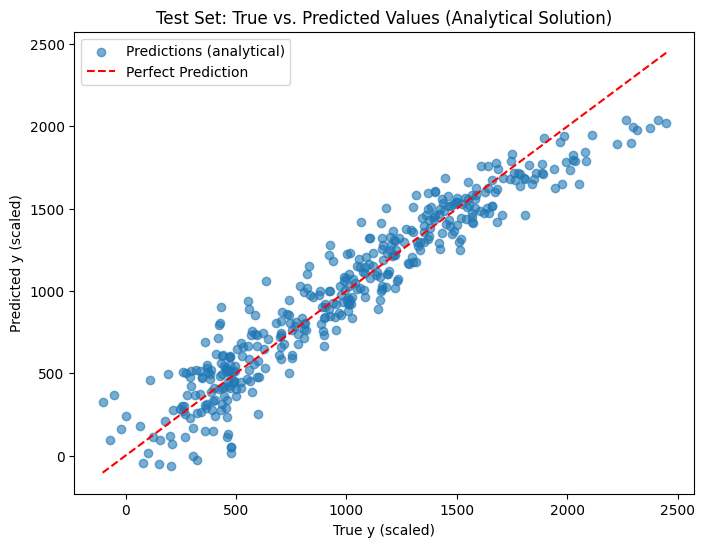

In [106]:
#Analytical solution
def analytical_solution(X, y, reg_lambda=0):
    n_samples = X.shape[0]
    #Add bias
    X_aug = np.hstack([np.ones((n_samples, 1)), X])
    n_features = X_aug.shape[1]
    # Regularization matrix
    L = reg_lambda * np.eye(n_features)
    L[0, 0] = 0  
    
    # Pseudoinverse 
    theta = np.linalg.pinv(X_aug.T @ X_aug + L) @ (X_aug.T @ y)
    return theta


theta_analytical = analytical_solution(X_train, y_train, reg_lambda=0)

X_val_aug = np.hstack([np.ones((X_val.shape[0], 1)), X_val])
y_val_pred_analytical = X_val_aug @ theta_analytical
val_mse_analytical = MSE(y_val, y_val_pred_analytical)

X_test_aug = np.hstack([np.ones((X_test.shape[0], 1)), X_test])
y_test_pred_analytical = X_test_aug @ theta_analytical
test_mse_analytical = MSE(y_test, y_test_pred_analytical)

print("Analitical solution:")
print("Params:", theta_analytical)
print("Loss MSE on validation set:", val_mse_analytical)
print("Loss MSE on test set:", test_mse_analytical)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred_analytical, alpha=0.6, label="Predictions (analytical)")
plt.xlabel('True y (scaled)')
plt.ylabel('Predicted y (scaled)')
plt.title('Test Set: True vs. Predicted Values (Analytical Solution)')
min_val = min(y_test.min(), y_test_pred_analytical.min())
max_val = max(y_test.max(), y_test_pred_analytical.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
plt.legend()
plt.show()


In [228]:
#konkurs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def MSE(y, y_pred):
    return np.mean((y - y_pred) ** 2)

def safe_polynomial(x):
    x = np.clip(x, -10, 10)
    return x ** 4

def model(X, w, bias):
    return safe_polynomial(np.dot(X, w) + bias)


def SGD_step(X, y, w, bias, lr, reg_type=None, reg_lambda=0, elastic_alpha=0.5):
    y_pred = model(X, w, bias)
    error = y_pred - y
    loss = MSE(y, y_pred)

    if reg_type == 'l1':
        reg_loss = reg_lambda * np.sum(np.abs(w))
        loss += reg_loss
        grad_reg = reg_lambda * np.sign(w)
    elif reg_type == 'l2':
        reg_loss = (reg_lambda / 2) * np.sum(w**2)
        loss += reg_loss
        grad_reg = reg_lambda * w
    elif reg_type == 'elastic':
        reg_loss = reg_lambda * (elastic_alpha * np.sum(np.abs(w)) + 
                                 (1 - elastic_alpha) / 2 * np.sum(w**2))
        loss += reg_loss
        grad_reg = reg_lambda * (elastic_alpha * np.sign(w) + (1 - elastic_alpha) * w)
    else:
        grad_reg = 0
    
    grad_w = np.dot(X.T, error) + grad_reg
    grad_bias = np.sum(error)

    grad_w = np.clip(grad_w, -5.0, 5.0)
    grad_bias = np.clip(grad_bias, -5.0, 5.0)

    w -= lr * grad_w
    bias -= lr * grad_bias
    
    return w, bias, loss

def train_model(X, y, w, bias, lr, epochs,
                reg_type=None, reg_lambda=0, elastic_alpha=0.5,
                batch_size=32):
    losses = []
    for epoch in range(epochs):
        epoch_loss = []
        indices = np.arange(len(y))
        np.random.shuffle(indices)
        
        for start in range(0, len(y), batch_size):
            end = start + batch_size
            batch_indices = indices[start:end]
            X_batch = X[batch_indices]
            y_batch = y[batch_indices]

            w, bias, loss = SGD_step(
                X_batch, y_batch, w, bias, lr,
                reg_type=reg_type, reg_lambda=reg_lambda, elastic_alpha=elastic_alpha
            )
            epoch_loss.append(loss)
        
        avg_epoch_loss = np.mean(epoch_loss)
        losses.append(avg_epoch_loss)
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {avg_epoch_loss:.5f}")
    
    return w, bias, losses


class CustomMinMaxScaler:
    def __init__(self, feature_range=(0, 1)):
        self.feature_range = feature_range
        self.data_min_ = None
        self.data_max_ = None

    def fit(self, X):
        X = np.asarray(X, dtype=np.float64)
        self.data_min_ = np.min(X, axis=0)
        self.data_max_ = np.max(X, axis=0)
        return self
    
    def transform(self, X):
        X = np.asarray(X, dtype=np.float64)
        X_std = (X - self.data_min_) / (self.data_max_ - self.data_min_)
        scale_min, scale_max = self.feature_range
        X_scaled = X_std * (scale_max - scale_min) + scale_min
        return X_scaled
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)


data = np.loadtxt('dane.data')  
X = data[:, 0:7]
y = data[:, -1]

scaler = CustomMinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)


best_lr = 0.00410
best_lambda = 0.01093
best_alpha = 0.79
epochs = 31
batch_size = 32

w_init = np.random.rand(X_scaled.shape[1])
bias_init = 0.2137

w_trained, bias_trained, losses_history = train_model(
    X_scaled, y, w_init, bias_init,
    lr=best_lr,
    epochs=epochs,
    reg_type='elastic',
    reg_lambda=best_lambda,
    elastic_alpha=best_alpha,
    batch_size=batch_size
)

predictions = model(X_scaled, w_trained, bias_trained)
error = predictions - y
SSE = np.sum(error ** 2)
RMSE = np.sqrt(SSE / len(y))

print("\nFinal model parameters (Elastic Net):")
print(f"w_trained = {w_trained}")
print(f"bias_trained = {bias_trained}")
print("\nRMSE on the entire dataset:", RMSE)


Epoch 0, Loss: 471607.34722
Epoch 10, Loss: 25626.18270
Epoch 20, Loss: 26547.19573
Epoch 30, Loss: 26084.84432

Final model parameters (Elastic Net):
w_trained = [ 0.65586643  1.70858645 -0.06468547  2.41303815  0.81006245 -0.0271793
  1.77638884]
bias_trained = 1.7765759847522127

RMSE on the entire dataset: 157.3700051468191
